In [ ]:
import pickle

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

import numpy as np
import scipy as sp

# Final plots for the paper Losing Dimensions

### Neural Network

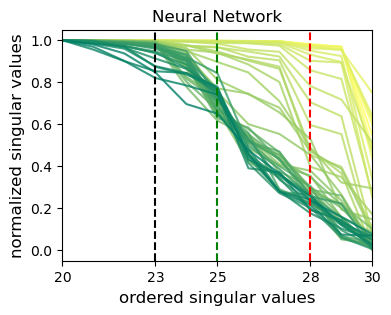

In [ ]:
t_steps = list(range(4, 100, 2))
start_t = 18
plot_from = 20
colors = plt.cm.summer(np.linspace(0, 1, len(t_steps))[::-1]) 

fig, ax = plt.subplots(figsize=(4, 3))
for t, color in zip(t_steps, colors):
    model_name = f'linear_model_spectrum_ds_500_N_30_s_1_d1_2_d2_5_v1_normalized.pickle'
    with open(f'pickles/{model_name}', 'rb') as handle:
        res_dict = pickle.load(handle)
        singular_values = res_dict['singular_values_orthg'][t][start_t:] / res_dict['singular_values_orthg'][t][start_t]
        alpha_val = t * 0.8 / max(t_steps)
        plt.plot(
            range(plot_from, len(singular_values) + 2 + start_t),
            singular_values[-11:],
            label=f't={t}',
            color=color,
            alpha=0.8
        )
plt.axvline(x=23, c="k", ls="--")
plt.axvline(x=25, c="g", ls="--")
plt.axvline(x=28, c="r", ls="--")
plt.ylabel('normalized singular values', fontsize=12)
plt.xlabel('ordered singular values', fontsize=12)
plt.title(f'Neural Network', fontsize=12)
plt.xlim(20,30)
plt.ylim(-0.05,1.05)
xticks = [20, 23, 25, 28, 30]
xtick_labels = [20, 23, 25, 28, 30]
plt.xticks(xticks, xtick_labels)

plt.savefig('nn_spectrum.pdf', bbox_inches='tight')

different dataset sizes

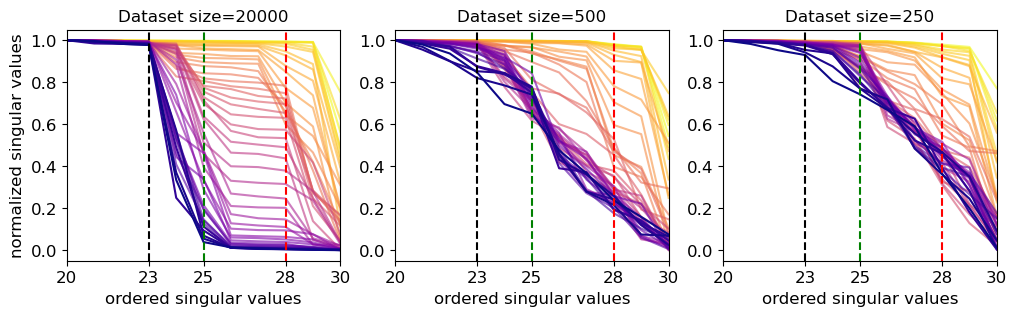

In [13]:
t_steps = list(range(4, 100, 2))
start_t = 18
plot_from = 20
colors = plt.cm.plasma(np.linspace(0, 1, len(t_steps))[::-1]) 

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, ds in enumerate([20000, 500, 250]):
    for t, color in zip(t_steps, colors):
        model_name = f'linear_model_spectrum_ds_{ds}_N_30_s_1_d1_2_d2_5_v1_normalized.pickle'
        with open(f'pickles/{model_name}', 'rb') as handle:
            res_dict = pickle.load(handle)
            singular_values = res_dict['singular_values_orthg'][t][start_t:] / res_dict['singular_values_orthg'][t][start_t]
            alpha_val = t * 0.8 / max(t_steps)
            if t >= t_steps[-5]:
                ax[i].plot(
                range(plot_from, len(singular_values) + 2 + start_t),
                singular_values[-11:],
                label=f't={t}',
                color=color
                )
            else:
                ax[i].plot(
                range(plot_from, len(singular_values) + 2 + start_t),
                singular_values[-11:],
                label=f't={t}',
                color=color,
                alpha=0.6
                )
    ax[i].axvline(x=23, c="k", ls="--")
    ax[i].axvline(x=25, c="g", ls="--")
    ax[i].axvline(x=28, c="r", ls="--")
    #ax[i].set_ylabel('normalized singular values', fontsize=12)
    ax[i].set_xlabel('ordered singular values', fontsize=12)
    ax[i].set_title(f'Dataset size={ds}', fontsize=12)
    ax[i].set_xlim([20,30])
    ax[i].set_xticks([20, 23, 25, 28, 30], [20, 23, 25, 28, 30])
    ax[i].set_ylim(-0.05,1.05)
ax[0].set_ylabel('normalized singular values', fontsize=12)
plt.savefig("nn_different_dataset_sizes.pdf", bbox_inches='tight')

different times

C:\Users\achillib\AppData\Local\Temp\ipykernel_6596\3142349643.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sv = np.array(res_dict['singular_values_orthg'][idx])


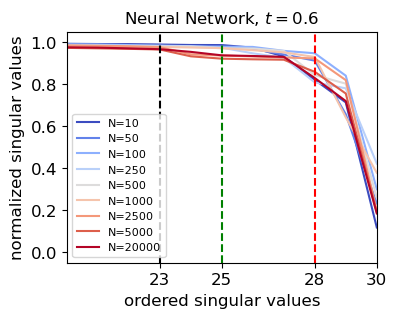

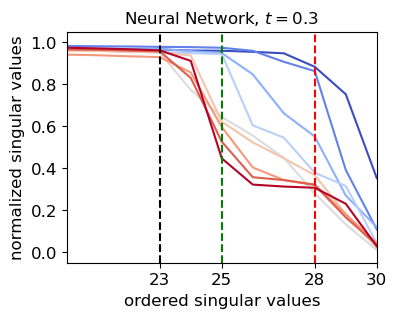

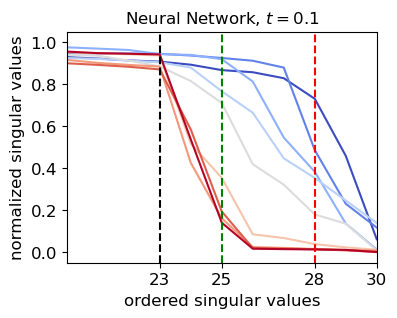

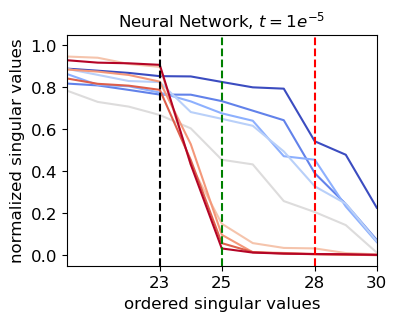

In [12]:

n_values = [10, 50, 100, 250, 500, 1000, 2500, 5000, 20000]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(n_values)))  # colormap

skip = 5
vlines = [23, 25, 28]

# parameters for each plot (inverse order)
indices = [24, 60, 86, 99]
titles  = [r"$t=0.6$", r"$t=0.3$", r"$t=0.1$", r"$t=1e^{-5}$"]

for i, (idx, tstr) in enumerate(zip(indices, titles)):
    plt.figure(figsize=(4, 3))

    for ds, color in zip(n_values, colors):
        model_name = f'linear_model_spectrum_ds_{ds}_N_30_s_1_d1_2_d2_5_v1_normalized.pickle'
        with open(f'pickles/{model_name}', 'rb') as handle:
            res_dict = pickle.load(handle)

        sv = np.array(res_dict['singular_values_orthg'][idx])
        sv_trimmed = sv[skip:]
        sv_norm = sv_trimmed / sv_trimmed.max()

        x = range(skip + 2, len(sv) + 2)
        lbl = f"N={ds}" if i == 0 else None  # legend only on first
        plt.plot(x, sv_norm, color=color, label=lbl)

    # Vertical lines
    for xline, c in zip(vlines, ["k", "g", "r"]):
        plt.axvline(x=xline, c=c, ls="--")

    # Consistent axes and ticks
    plt.xlim(20, 30)
    plt.ylim(-0.05, 1.05)

    current_ticks = plt.xticks()[0]
    new_ticks = sorted(set(vlines + [30]))
    plt.xticks(new_ticks)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

    # Labels and title
    plt.xlabel("ordered singular values", fontsize=12)
    plt.ylabel("normalized singular values", fontsize=12)
    plt.title(rf"Neural Network, {tstr}", fontsize=12)

    # Legend only on first plot
    if i == 0:
        plt.legend(loc='lower left', fontsize=8)

   
    # fname = f"plots/NN_spectrum_norm_{tstr.replace('$','').replace('=','_').replace('^','')}_1.pdf"
    # plt.savefig(fname, bbox_inches='tight')
    plt.show()


### Empirical Score 

In [3]:
def score_function(corrupted_patterns, patterns, sigma):
  weights = sp.special.softmax(-np.sum((np.expand_dims(corrupted_patterns, 1) - np.expand_dims(patterns, 0))**2, 2)/(2*sigma), 1)
  prodiction = np.matmul(weights, patterns)
  reg_score = (-corrupted_patterns + prodiction)/sigma
  return reg_score

def estimate_spectrum_ortho(test_point,patterns,sigma,stdv):
   d = test_point.shape[1]
   dx = np.diag(np.sqrt(sigma)*np.random.normal(1,stdv,d))
   J = (score_function(test_point + dx/2, patterns, sigma) - score_function(test_point - dx/2, patterns, sigma))/(np.sqrt(sigma)*np.sign((score_function(test_point + dx/2, patterns, sigma) - score_function(test_point - dx/2, patterns, sigma))))
   u,s,v = np.linalg.svd(J)
   return s

def generate_linear_data(sigma1,sigma2,sigma3,d1,d2,d3,N, normalized=False):
  scales = np.concatenate((sigma1*np.ones((d1,)), sigma2*np.ones((d2,)), sigma3*np.ones((d3,))), 0)
  samples = np.expand_dims(scales,0)*np.random.normal(0, 1, (N,d1+d2+d3))
  if normalized:
    samples = samples/np.linalg.norm(samples,axis=1,keepdims=True)
  return samples

In [4]:
np.random.seed(2)#1
dim = 30  #30
d1 = 2  #2
d2 = 5  #5
N = 1000  #1000
num_reps = 5  #5
scale = 1.0  #1.0
is_normalized = True
samples = generate_linear_data(scale*1.,scale*0.3, scale*0.01, d1, d2, d3=dim - d1 - d2, N=N, normalized=is_normalized)

sigma_range = np.linspace(1,0.01,100)
singular_values = []
for sigma in reversed(sigma_range):
  s_avg = 0.
  for _ in range(num_reps):
    if is_normalized:
        test_point = np.zeros((1,dim))
    else:
      test_point = np.zeros((1,dim))
    s = estimate_spectrum_ortho(test_point,samples,sigma*scale,0)
    s_avg += s
  singular_values.append(s_avg/num_reps)

[20 23 25 28 30]


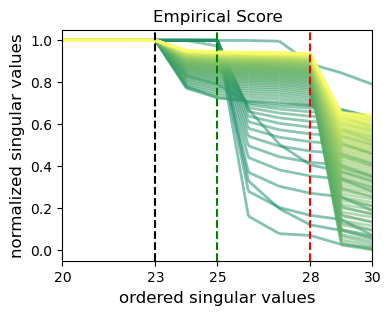

In [ ]:
in_idx = 6

num_sigmas = 100

cmap = plt.get_cmap('summer')  
norm = Normalize(vmin=0, vmax=num_sigmas-1)

fig, ax = plt.subplots(figsize=(4, 3))

for idx in range(2,num_sigmas):
    data = (singular_values[idx][in_idx:] / np.max(singular_values[idx][in_idx:]))
    
    points = np.array([np.arange(len(data)), data]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=cmap, norm=norm,alpha = 0.5)
    lc.set_array(np.full(len(segments), idx)) 
    lc.set_linewidth(2) 
    
    plt.gca().add_collection(lc)

plt.title('Empirical Score', fontsize = 12)
plt.xlabel("ordered singular values", fontsize = 12)
plt.ylabel("normalized singular values", fontsize = 12)

plt.axvline(x = dim - d1 - d2 - in_idx-1, c="k", ls="--")
plt.axvline(x = dim - d1 - in_idx-1, c="r", ls="--")
plt.axvline(x = dim - d2 - in_idx-1, c="g", ls="--")
old_ticks = [13, 16, 18, 21, 23]
ticks = (list(old_ticks) + np.ones(len(old_ticks))*7).astype(int)  
custom_xticks = old_ticks  
custom_xtick_labels = ticks  
print(ticks)
plt.xticks(custom_xticks, custom_xtick_labels)
plt.ylim(-0.05,1.05)
plt.xlim(13,23)

plt.savefig("empirical_score_simulation.pdf", bbox_inches='tight')
plt.show()

### Theoretical spectrum

In [6]:
dim = 30 #30
d1 = 2 #5
d2 = 5 #10
N = 1000
num_reps = 5#3
scale = 1
sd1 = 1*scale
sd2 = 0.3*scale
is_normalized = True

In [7]:
scales = np.concatenate((sd1*np.ones((d1,)),
                    sd2*np.ones((d2,)),
                    0.000001*scale*np.ones((dim - d1 - d2,))))
eigenvalues = lambda t: 1./(t + scales**2)

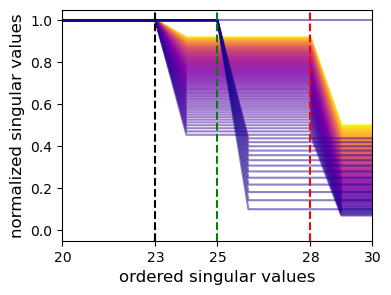

In [ ]:
t_range = np.linspace(1,0.005,200)
norm = plt.Normalize(vmin=np.min(t_range), vmax=np.max(t_range))
cmap = cm.plasma

in_idx = 7

fig, ax = plt.subplots(figsize=(4, 3))

gate = 0. if is_normalized else 1.
t_c = lambda t: np.sqrt((1/(2*np.log(N)))*(gate*np.sum(scales**4)/2 + t*scales**2))
t_c0 = np.sqrt((1/(2*np.log(N)))*(gate*np.sum(scales**4)/2))
phi = lambda t: np.maximum(0, t**(-1) - t_c(t)**(-1))
phi0 = lambda t: np.maximum(0, t**(-1) - t_c0**(-1)) if not is_normalized else 0.
factor = lambda t: np.sum(scales**2/(t**2*(t + scales**2)))

variances = lambda t: factor(t)*(phi0(t) + phi(t))
singular = lambda t: np.sqrt(eigenvalues(t)**2 + variances(t)**2) 

for t in t_range:
    color = cmap(norm(t)) 
    plt.plot(np.sort(singular(t))[::-1][in_idx:] / np.max(np.sort(singular(t))[::-1][in_idx:]),label='%.3f' % t, color=color,alpha = 0.5)

plt.axvline(x=dim - d1 - in_idx-1, ls="--", c="red")
plt.axvline(x=dim - d2 - in_idx-1, ls="--", c="green")
plt.axvline(x=dim - (d1 + d2 + in_idx)-1, ls="--", c="black")

custom_xticks = [12, 15, 17, 20, 22] 
custom_xtick_labels = (list(custom_xticks) + np.ones(len(custom_xticks))*8).astype(int)   
plt.xticks(custom_xticks, custom_xtick_labels)
plt.xlim(12,22)
plt.ylim(-0.05,1.05)
plt.title('Theory', fontsize = 12)
plt.xlabel("ordered singular values", fontsize = 12)
plt.ylabel("normalized singular values", fontsize = 12)
plt.savefig('analytical_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

### Plot things together

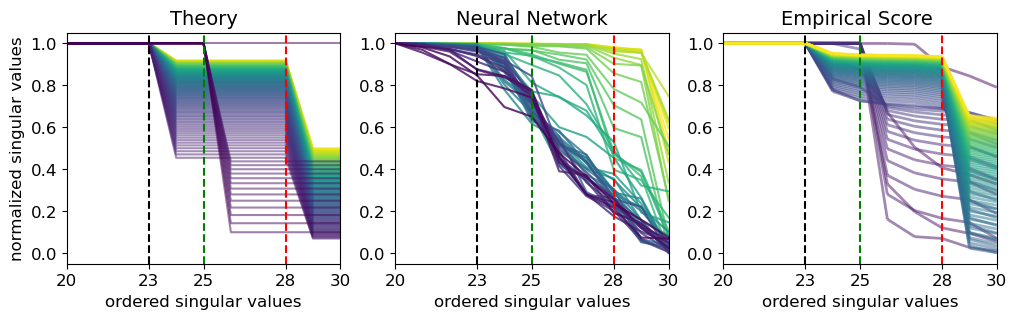

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import FixedLocator

FIGSIZE = (12, 3)          
CMAP_NAME = "viridis"
TITLE_SIZE = 14
LABEL_SIZE = 12

plt.rcParams.update({
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": LABEL_SIZE,
    "ytick.labelsize": LABEL_SIZE,
})
cmap = plt.get_cmap(CMAP_NAME)

def setup_ax(ax, title):
    ax.set_title(title)
    ax.grid(False)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, sharex=False, sharey=False, constrained_layout=False)
# fig.subplots_adjust(left=0.08, right=0.985, bottom=0.18, top=0.88, wspace=0.22)

# ===================== PLOT 1 =====================
ax = axes[0]
setup_ax(ax, "Theory")

dim = 30 
d1 = 2 
d2 = 5 
N = 1000
num_reps = 5
scale = 1
sd1 = 1*scale
sd2 = 0.3*scale
is_normalized = True

scales = np.concatenate((sd1*np.ones((d1,)),
                    sd2*np.ones((d2,)),
                    0.000001*scale*np.ones((dim - d1 - d2,))))
eigenvalues = lambda t: 1./(t + scales**2)

t_range = np.linspace(1,0.005,200)
norm = plt.Normalize(vmin=np.min(t_range), vmax=np.max(t_range))


in_idx = 7

gate = 0. if is_normalized else 1.
t_c = lambda t: np.sqrt((1/(2*np.log(N)))*(gate*np.sum(scales**4)/2 + t*scales**2))
t_c0 = np.sqrt((1/(2*np.log(N)))*(gate*np.sum(scales**4)/2))
phi = lambda t: np.maximum(0, t**(-1) - t_c(t)**(-1))
phi0 = lambda t: np.maximum(0, t**(-1) - t_c0**(-1)) if not is_normalized else 0.
factor = lambda t: np.sum(scales**2/(t**2*(t + scales**2)))

variances = lambda t: factor(t)*(phi0(t) + phi(t))
singular = lambda t: np.sqrt(eigenvalues(t)**2 + variances(t)**2) 

for t in t_range:
    color = cmap(norm(t)) 
    ax.plot(np.sort(singular(t))[::-1][in_idx:] / np.max(np.sort(singular(t))[::-1][in_idx:]),label='%.3f' % t, color=color,alpha = 0.5)

ax.axvline(x=dim - d1 - in_idx-1, ls="--", c="red")
ax.axvline(x=dim - d2 - in_idx-1, ls="--", c="green")
ax.axvline(x=dim - (d1 + d2 + in_idx)-1, ls="--", c="black")

custom_xticks = [12, 15, 17, 20, 22] 
custom_xtick_labels = (list(custom_xticks) + np.ones(len(custom_xticks))*8).astype(int)   
ax.set_xticks(custom_xticks, custom_xtick_labels)
ax.set_xlim(12,22)
ax.set_ylim(-0.05,1.05)
# ax.set_title('Theory', fontsize = 12)

ax.set_xlabel("ordered singular values")
ax.set_ylabel("normalized singular values")

# ===================== PLOT 2 =====================
ax = axes[1]
setup_ax(ax, "Neural Network")

t_steps = list(range(4, 100, 2))
start_t = 18
plot_from = 20
colors = plt.cm.viridis(np.linspace(0, 1, len(t_steps))[::-1]) # Adjust colormap as needed

for t, color in zip(t_steps, colors):
    model_name = f'linear_model_spectrum_ds_500_N_30_s_1_d1_2_d2_5_v1_normalized.pickle'
    with open(f'pickles/{model_name}', 'rb') as handle:
        res_dict = pickle.load(handle)
        singular_values = res_dict['singular_values_orthg'][t][start_t:] / res_dict['singular_values_orthg'][t][start_t]
        alpha_val = t * 0.8 / max(t_steps)
        ax.plot(
            range(plot_from, len(singular_values) + 2 + start_t),
            singular_values[-11:],
            label=f't={t}',
            color=color,
            alpha=0.8
        )
ax.axvline(x=23, c="k", ls="--")
ax.axvline(x=25, c="g", ls="--")
ax.axvline(x=28, c="r", ls="--")
# ax.set_ylabel('normalized singular values', fontsize=12)
# ax.set_xlabel('ordered singular values', fontsize=12)
# ax.set_title(f'Neural Network', fontsize=12)
ax.set_xlim(20,30)
ax.set_ylim(-0.05,1.05)
xticks = [20, 23, 25, 28, 30]
xtick_labels = [20, 23, 25, 28, 30]
ax.set_xticks(xticks, xtick_labels)

ax.set_xlabel("ordered singular values")

# ===================== PLOT 3 =====================
ax = axes[2]
setup_ax(ax, "Empirical Score ")

np.random.seed(2)
dim = 30  
d1 = 2  
d2 = 5  
N = 1000  
num_reps = 5  
scale = 1.0  
is_normalized = True
samples = generate_linear_data(scale*1.,scale*0.3, scale*0.01, d1, d2, d3=dim - d1 - d2, N=N, normalized=is_normalized)

sigma_range = np.linspace(1,0.01,100)
singular_values = []
for sigma in reversed(sigma_range):
  s_avg = 0.
  for _ in range(num_reps):
    if is_normalized:
        test_point = np.zeros((1,dim))
    else:
      test_point = np.zeros((1,dim))
    s = estimate_spectrum_ortho(test_point,samples,sigma*scale,0)
    s_avg += s
  singular_values.append(s_avg/num_reps)

in_idx = 6

num_sigmas = 100

cmap = plt.get_cmap('viridis')  
norm = Normalize(vmin=0, vmax=num_sigmas-1)


for idx in range(2,num_sigmas):
    data = (singular_values[idx][in_idx:] / np.max(singular_values[idx][in_idx:]))
    
    points = np.array([np.arange(len(data)), data]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=cmap, norm=norm,alpha = 0.5)
    lc.set_array(np.full(len(segments), idx)) 
    lc.set_linewidth(2) 
    
    ax.add_collection(lc)

ax.axvline(x = dim - d1 - d2 - in_idx-1, c="k", ls="--")
ax.axvline(x = dim - d1 - in_idx-1, c="r", ls="--")
ax.axvline(x = dim - d2 - in_idx-1, c="g", ls="--")

custom_xticks = [13, 16, 18, 21, 23]  
custom_xtick_labels = (list(custom_xticks) + np.ones(len(custom_xticks))*7).astype(int)  

ax.set_xticks(custom_xticks, custom_xtick_labels)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(13,23)

ax.set_xlabel("ordered singular values", fontsize = 12)

fig.savefig("three_subplots.pdf", bbox_inches='tight')
fig.savefig("three_subplots.png", bbox_inches='tight', dpi=300)
plt.show()
